In [8]:
import pandas as pd

pd.read_csv('../data/merged/panel_final_1992_2024.csv')

,recipient_iso3,year,arms_tiv_total,oda_total,econ_neocol_score_total,colonial_tie_flag,journalist_killings,gdp_per_capita,gdp_per_capita_log,population,...,econ_neocol_score_in_strength_lag1,econ_neocol_score_out_strength_lag1,econ_neocol_score_dependency_balance_lag1,econ_neocol_score_in_concentration_lag1,econ_neocol_score_pagerank_lag1,arms_tiv_total_log,oda_total_log,arms_tiv_total_log_lag1,oda_total_log_lag1,econ_neocol_score_total_lag1
0,ABW,1992,0.0,29.850000,0.000000,0,0,13892.605143,9.539112,69005.0,...,NaN,NaN,NaN,NaN,NaN,0.000000,3.429137,NaN,NaN,NaN
1,ABW,1993,0.0,22.970000,0.000000,0,0,14700.959808,9.595668,73685.0,...,0.000000,0.0,0.000000,0.000000,0.004878,0.000000,3.176803,0.000000,3.429137,0.000000
2,ABW,1994,0.0,15.930000,0.000000,0,0,16055.287787,9.683794,77595.0,...,0.000000,0.0,0.000000,0.000000,0.004785,0.000000,2.829087,0.000000,3.176803,0.000000
3,ABW,1995,0.0,17.980000,0.000000,0,0,16548.717387,9.714064,79805.0,...,0.000000,0.0,0.000000,0.000000,0.004808,0.000000,2.943386,0.000000,2.829087,0.000000
4,ABW,1996,0.0,20.330000,0.000000,0,0,16620.954556,9.718420,83021.0,...,0.000000,0.0,0.000000,0.000000,0.004126,0.000000,3.060115,0.000000,2.943386,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6353,ZWE,2020,0.0,575.408069,5.644980,1,0,2059.674454,7.630303,15526888.0,...,33.841162,0.0,3.550800,0.068608,0.004848,0.000000,6.356816,0.000000,6.270739,5.438529
6354,ZWE,2021,0.0,585.226704,5.445494,1,0,2613.605421,7.868486,15797210.0,...,37.344240,0.0,3.646604,0.064271,0.005112,0.000000,6.373707,0.000000,6.356816,5.644980
6355,ZWE,2022,0.0,474.199097,6.034512,1,0,2536.400502,7.838501,16069056.0,...,31.548008,0.0,3.482716,0.070762,0.004628,0.000000,6.163734,0.000000,6.373707,5.445494
6356,ZWE,2023,20.4,475.299393,6.044402,1,0,2195.224921,7.694040,16340822.0,...,41.391372,0.0,3.746945,0.063217,0.005069,3.063391,6.166047,0.000000,6.163734,6.034512


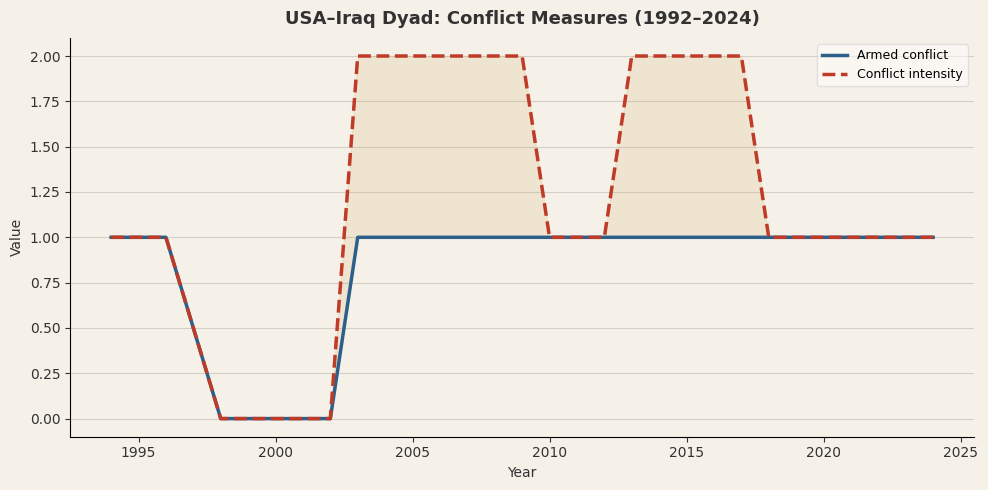

Saved.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Colors (your palette)
# -----------------------------
RED   = '#BF3A27'
GOLD  = '#C7922A'
DARK  = '#323232'
LIGHT = '#F5F0E8'
GRAY  = '#888780'
BLUE  = '#2C5F8A'

US_COLOR  = BLUE
IRQ_COLOR = RED

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("../data/merged/dyadic_panel_1992_2024_oda_capped_log.csv")

df["armed_conflict"] = pd.to_numeric(df["armed_conflict"], errors="coerce")
df["conflict_intensity"] = pd.to_numeric(df["conflict_intensity"], errors="coerce")

# -----------------------------
# Filter ONLY US–IRQ dyads
# -----------------------------
us_irq = df[
    ((df["sender_iso3"] == "USA") & (df["recipient_iso3"] == "IRQ")) |
    ((df["sender_iso3"] == "IRQ") & (df["recipient_iso3"] == "USA"))
].copy()

# -----------------------------
# Aggregate by year
# -----------------------------
us_irq_year = (
    us_irq.groupby("year")[["armed_conflict", "conflict_intensity"]]
    .mean()
    .reset_index()
)

# -----------------------------
# Plot (styled like your example)
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 5), facecolor=LIGHT)

ax.set_facecolor(LIGHT)

ax.plot(us_irq_year["year"], us_irq_year["armed_conflict"],
        color=US_COLOR, linewidth=2.5, label="Armed conflict")

ax.plot(us_irq_year["year"], us_irq_year["conflict_intensity"],
        color=IRQ_COLOR, linewidth=2.5, linestyle="--",
        label="Conflict intensity")

# Fill between (visual emphasis like your example)
ax.fill_between(
    us_irq_year["year"],
    us_irq_year["armed_conflict"],
    us_irq_year["conflict_intensity"],
    alpha=0.12,
    color=GOLD
)

# -----------------------------
# Styling
# -----------------------------
ax.set_title("USA–Iraq Dyad: Conflict Measures (1992–2024)",
             fontsize=13, color=DARK, fontweight='bold', pad=10)

ax.set_xlabel("Year", color=DARK)
ax.set_ylabel("Value", color=DARK)

ax.tick_params(colors=DARK)
ax.spines[['top', 'right']].set_visible(False)

ax.grid(axis='y', alpha=0.3, color=GRAY)

ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.savefig("../outputs/case_study/fig_us_irq_conflict.png",
            dpi=150, bbox_inches='tight', facecolor=LIGHT)

plt.show()

print("Saved.")

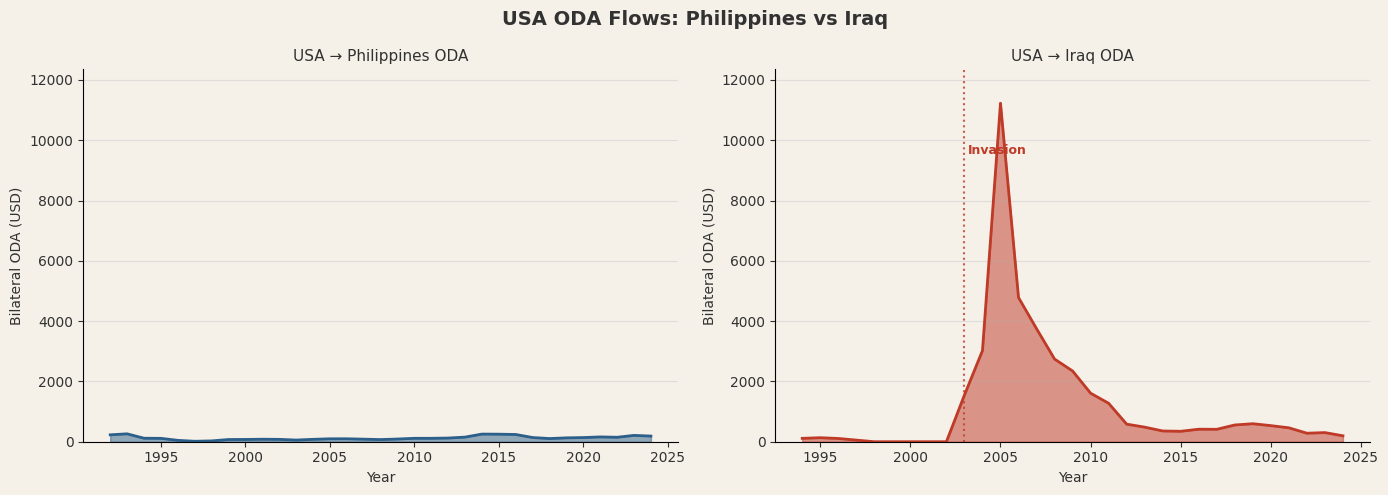

Saved.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Colors
# -----------------------------
RED   = '#BF3A27'
GOLD  = '#C7922A'
DARK  = '#323232'
LIGHT = '#F5F0E8'
BLUE  = '#2C5F8A'

PHL_COLOR = BLUE
IRQ_COLOR = RED

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("../data/merged/dyadic_panel_1992_2024_oda_capped_log.csv")

# -----------------------------
# Filter dyads (USA → PHL, USA → IRQ)
# -----------------------------
usa_phl = df[
    (df["sender_iso3"] == "USA") &
    (df["recipient_iso3"] == "PHL")
].sort_values("year")

usa_irq = df[
    (df["sender_iso3"] == "USA") &
    (df["recipient_iso3"] == "IRQ")
].sort_values("year")

# -----------------------------
# Shared ODA y-axis
# -----------------------------
oda_max = 0

if len(usa_phl):
    oda_max = max(oda_max, usa_phl["bilateral_oda"].max())
if len(usa_irq):
    oda_max = max(oda_max, usa_irq["bilateral_oda"].max())

oda_ylim = (0, oda_max * 1.1 if oda_max > 0 else 1)

# -----------------------------
# Figure (2 ODA plots only)
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=LIGHT)
fig.suptitle('USA ODA Flows: Philippines vs Iraq',
             fontsize=14, color=DARK, fontweight='bold')

# =============================
# USA → PHILIPPINES ODA
# =============================
ax = axes[0]
ax.set_facecolor(LIGHT)

if len(usa_phl):
    ax.fill_between(usa_phl["year"], usa_phl["bilateral_oda"],
                    alpha=0.5, color=PHL_COLOR)
    ax.plot(usa_phl["year"], usa_phl["bilateral_oda"],
            color=PHL_COLOR, linewidth=2)

ax.set_title("USA → Philippines ODA", color=DARK, fontsize=11)
ax.set_ylabel("Bilateral ODA (USD)", color=DARK)
ax.set_ylim(oda_ylim)

ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=DARK)
ax.grid(axis='y', alpha=0.3)

# =============================
# USA → IRAQ ODA
# =============================
ax = axes[1]
ax.set_facecolor(LIGHT)

if len(usa_irq):
    ax.fill_between(usa_irq["year"], usa_irq["bilateral_oda"],
                    alpha=0.5, color=IRQ_COLOR)
    ax.plot(usa_irq["year"], usa_irq["bilateral_oda"],
            color=IRQ_COLOR, linewidth=2)

# Invasion marker + label
ax.axvline(2003, color=IRQ_COLOR, linestyle=':', alpha=0.8)
ax.text(2003 + 0.2,
        usa_irq["bilateral_oda"].max() * 0.85,
        "Invasion",
        fontsize=9,
        color=IRQ_COLOR,
        fontweight='bold')

ax.set_title("USA → Iraq ODA", color=DARK, fontsize=11)
ax.set_ylabel("Bilateral ODA (USD)", color=DARK)
ax.set_ylim(oda_ylim)

ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=DARK)
ax.grid(axis='y', alpha=0.3)

# -----------------------------
# Shared x-labels
# -----------------------------
for ax in axes:
    ax.set_xlabel("Year", color=DARK)

plt.tight_layout()

plt.savefig("../outputs/case_study/fig_oda_phl_irq.png",
            dpi=150, bbox_inches='tight', facecolor=LIGHT)

plt.show()

print("Saved.")

In [13]:
import pandas as pd

df = pd.read_csv("../data/merged/dyadic_panel_1992_2024_oda_capped_log.csv")

usa_phl = (
    df[(df["sender_iso3"] == "USA") &
       (df["recipient_iso3"] == "PHL")]
    .copy()
    .sort_values("year")
)

usa_phl.head()

,sender_iso3,recipient_iso3,year,arms_tiv,bilateral_oda,econ_neocol_score,colonial_tie,journalist_killings,gdp_per_capita,gdp_per_capita_log,population,population_log,armed_conflict,conflict_intensity,econ_neocol_score_log
11338,USA,PHL,1992,42.24,229.0,NaN,0,4,916.515695,6.820579,65926125.0,18.004045,1.0,1.0,NaN
11339,USA,PHL,1993,44.64,262.0,NaN,0,3,918.642954,6.822898,67530621.0,18.028092,1.0,1.0,NaN
11340,USA,PHL,1994,42.50,116.0,NaN,0,0,1059.983895,6.966009,69019291.0,18.049897,1.0,1.0,NaN
11341,USA,PHL,1995,3.50,112.0,1.509546e-07,0,0,1199.841714,7.089945,70546246.0,18.071779,1.0,1.0,5.023582
11342,USA,PHL,1996,1.50,46.0,1.697067e-07,0,2,1311.092494,7.178616,72190242.0,18.094815,1.0,1.0,5.139947


In [14]:
import pandas as pd

df = pd.read_csv("../data/merged/dyadic_panel_1992_2024_oda_capped_log.csv")

usa_irq = (
    df[(df["sender_iso3"] == "USA") &
       (df["recipient_iso3"] == "IRQ")]
    .copy()
    .sort_values("year")
)

usa_irq.head()

,sender_iso3,recipient_iso3,year,arms_tiv,bilateral_oda,econ_neocol_score,colonial_tie,journalist_killings,gdp_per_capita,gdp_per_capita_log,population,population_log,armed_conflict,conflict_intensity,econ_neocol_score_log
109653,USA,IRQ,1994,0.0,112.00,NaN,0,1,198.182102,5.289186,20139807.0,16.818209,1.0,1.0,NaN
109654,USA,IRQ,1995,0.0,133.00,1.991619e-11,0,0,619.135531,6.428324,20825860.0,16.851706,1.0,1.0,0.019720
109655,USA,IRQ,1996,0.0,108.00,1.336439e-10,0,0,485.258493,6.184682,21501321.0,16.883625,1.0,1.0,0.125437
109656,USA,IRQ,1998,0.0,0.00,9.878101e-08,0,0,900.937143,6.803435,22884399.0,16.945966,0.0,0.0,4.602978
109657,USA,IRQ,2002,0.0,0.04,2.891467e-07,0,0,1266.159613,7.143744,26006559.0,17.073859,0.0,0.0,5.670387


In [18]:
print("PHL ODA summary:")
print(usa_phl["bilateral_oda"].describe())

print("\nIRQ ODA summary:")
print(usa_irq["bilateral_oda"].describe())

PHL ODA summary:
count     33.000000
mean     125.816229
std       66.412787
min       15.000000
25%       79.450000
50%      113.430000
75%      153.080000
max      262.000000
Name: bilateral_oda, dtype: float64

IRQ ODA summary:
count       27.000000
mean      1414.147156
std       2323.307966
min          0.000000
25%        292.734735
50%        483.820000
75%       1579.470000
max      11227.790000
Name: bilateral_oda, dtype: float64
